In [2]:
import os
dir = os.path.abspath('')  # directory of notebook
import sys
sys.path.append(os.path.join(dir, '..', '..'))  # package directory
from src.FoKL import FoKLRoutines
from src.FoKL.fokl_to_pyomo import fokl_to_pyomo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pyomo.dae as dae
from scipy.interpolate import interp1d

In [3]:
data = pd.read_csv("step_tests.csv")

tvec = data["Time"].values
Tabs = data["T1"].values
u = data["Q1"].values

t0 = tvec[0]
tf = tvec[-1]
dt = (tf - t0) / (len(tvec) - 1)

Tamb = Tabs[0]
T = Tabs - Tamb

In [4]:
def smooth(x, window):
    """Apply centered average of size window."""
    x_smooth = np.zeros_like(x)
    w2 = int(np.floor(window / 2))
    w2p1 = w2 + 1

    # bleed in:
    for i in range(w2):
        x_smooth[i] = np.mean(x[:(i + w2p1)])

    # center:
    for i in range(w2, x_smooth.size - w2):
        x_smooth[i] = np.mean(x[(i - w2):(i + w2p1)])

    # bleed out:
    for i in range(-w2, 0):
        x_smooth[i] = np.mean(x[(i - w2)::])

    return x_smooth


def gradient_h4(x, h):
    """h is step size. Order of error is h^4."""
    dx = np.zeros_like(x)

    # bleed in:
    h2 = 2 * h
    dx[0] = (x[1] - x[0]) / h
    dx[1] = (x[2] - x[0]) / h2

    # center difference:
    h12 = 12 * h
    for i in range(2, x.shape[0] - 2):
        dx[i] = (x[i - 2] - 8 * x[i - 1] + 8 * x[i + 1] - x[i + 2]) / h12
    
    # bleed out:
    dx[-2] = (x[-1] - x[-3]) / h2
    dx[-1] = (x[-1] - x[-2]) / h

    return dx

In [5]:
T = smooth(T, 9)  # smooth
dT = gradient_h4(T, dt)  # derivative of smoothed

In [6]:
filename = os.path.join(dir, "models", "fokl_to_pyomo_validation.fokl")
try:
    GP = FoKLRoutines.load(filename)
except Exception as exception:
    GP = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True)
    GP.fit([T, u], dT, clean=True, pillow=[[0.01, 0.05], [0, 0]])
    GP.save(filename)

In [18]:
m = pyo.ConcreteModel("TCLab Heater with GP Model")
m.t = dae.ContinuousSet(bounds=(t0, tf))
m.T = pyo.Var(m.t, bounds = GP.minmax[0])
m.u = pyo.Var(m.t, bounds = GP.minmax[1])
m.dT = dae.DerivativeVar(m.T, wrt=m.t)

nfe = len(tvec)
pyo.TransformationFactory('dae.finite_difference').apply_to(m, nfe=nfe)

ival = np.linspace(0, len(tvec) - 1, nfe + 1, dtype=int)
i = {}
ind = -1
for t in m.t:
    ind += 1
    i.update({t: ival[ind]})

    m.T[t].fix(T[i[t]])
    m.u[t].fix(u[i[t]])

fokl_to_pyomo(GP, [m.T, m.u], m.dT, m, m.t)  # note to get 'm.GP0_y' to calculate, define 'nfe' and fix prior to 'fokl_to_pyomo'

c:\Users\jakep\ESMS\dev\tclab\examples\pyomo_tclab\..\..\src\FoKL\FoKLRoutines.py:290: UserWarning: 'inputs' was transposed. Ignore if more datapoints than input variables, else set 'AutoTranspose=False' to disable.
  warnings.warn("'inputs' was transposed. Ignore if more datapoints than input variables, else set "


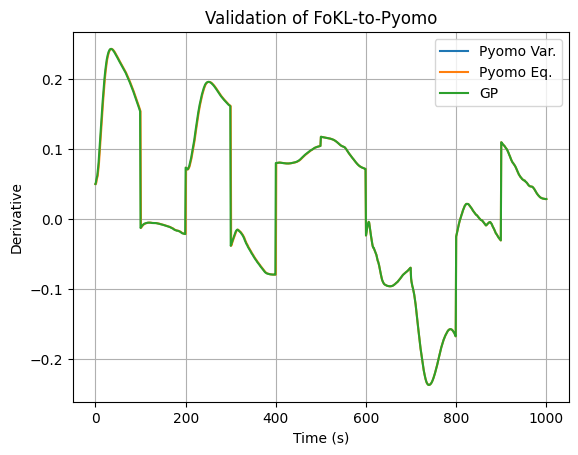

In [17]:
plt.plot(m.t, m.dT[:](), label="Pyomo Var.")
plt.plot(m.t, m.GP0_y[:](), label="Pyomo Eq.")
plt.plot(tvec[ival], GP.evaluate([T[ival], u[ival]], clean=True), label="GP")
plt.title("Validation of FoKL-to-Pyomo")
plt.xlabel("Time (s)")
plt.ylabel("Derivative")
plt.legend()
plt.grid()